In [65]:
import numpy as np
import matplotlib.pyplot as plt
import math

## 1. Viết hàm tính độ đo F1-Score thường được sử dụng để đánh giá mô hình phân loại.

Lỗi code: 
* not instance không phải instance
* Dùng if không dùng elif -> chỉ kiểm tra được 1 cái

Thêm kỹ thuật kiểm tra:
* precision = tp / (tp + fp) if (tp + fp) != 0 else 0
* recall = tp / (tp + fn) if (tp + fn) != 0 else 0

In [12]:
def evaluate_f1_score(tp, fp, fn):
    if not isinstance(tp, int):
        print("tn must be int")
        return
    if not isinstance(fp, int):
        print("fp must be int")
        return
    if not isinstance(fn, int):
        print("fn must be int")
        return
    elif tp < 0 or fp < 0 or fn < 0:
        print("tp and fp and fn must be greater than or equal zero")
        return
    
    recall = 0
    precision = 0
    f1_score = 0
    if tp + fp != 0:
        precision = tp / (tp + fp)
    else:
        print("(tp + fp) must be greater than 0")
        return 0, 0, 0
    
    if tp + fn != 0:
        recall = tp / (tp + fn)
    else:
        print("(tp + fn) must be greater than 0")
        return 0, 0, 0

    if precision + recall != 0:
        f1_score = 2 * precision * recall / (precision + recall)
    else:
        print("(precision + recall) must be greater than 0")
        return 0, 0, 0
    
    return precision, recall, f1_score

precision, recall, f1_score = evaluate_f1_score(tp = 8, fp = 2, fn = 3)
print("precision:", precision)
print("recall:", recall)
print("f1_score:", f1_score)

precision: 0.8
recall: 0.7272727272727273
f1_score: 0.761904761904762


In [13]:
precision, recall, f1_score = evaluate_f1_score(tp = 0, fp = 0, fn = 1)
print("precision:", precision)
print("recall:", recall)
print("f1_score:", f1_score)

(tp + fp) must be greater than 0
precision: 0
recall: 0
f1_score: 0


## 2. Viết hàm tính giá trị cho các hàm số kích hoạt

**Sigmoid**
* Hàm sigmoid: $y = 1 / (1 + np.exp(-z))$

**ReLU**
* Hàm ReLU: $y = max(0, x)$

**ELU**
* Hàm ELU (Exponential Linear Unit): 
    * if x > 0: y = x
    * if x <= 0: y = alpha * (exp(x) - 1)

In [68]:
def is_number(n):
    try:
        float(n)
    except ValueError:
        return False
    return True

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def elu(z, alpha): 
    if z >= 0:
        return alpha * (np.exp(z) - 1)
    return z


In [ ]:

def visualize(x, func=''):
    # plt.figure(figsize=(8, 6))
    y = []
    if func == 'sigmoid':
        y = sigmoid(x)
    if func == 'relu':
        y = relu(x)
    if func == 'elu':
        y = elu(x, 1)

    plt.scatter(x, y)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Scatter plot")
    plt.show()

<class 'numpy.ndarray'>
[ 6.38629158 -8.3688343   1.57781662  4.503052   -3.78071964  9.9561604
 -9.41578295 -5.17259413 -8.98780859 -1.14424937  7.63303925  7.80539172
  8.91973346  6.92443852 -1.89366199  3.20783216 -2.89813738 -1.70986413
  6.4592298  -7.71348867 -6.56095151  6.6471887   4.89745919 -6.38896979
  3.66393122  9.95937101  7.50753175 -0.26327603 -6.1660896   8.1419992
  3.86911286 -9.88333608 -9.08989307 -7.29218342  6.65704055  9.67444975
  9.33900271  2.93516479  4.37424892  1.91497521]


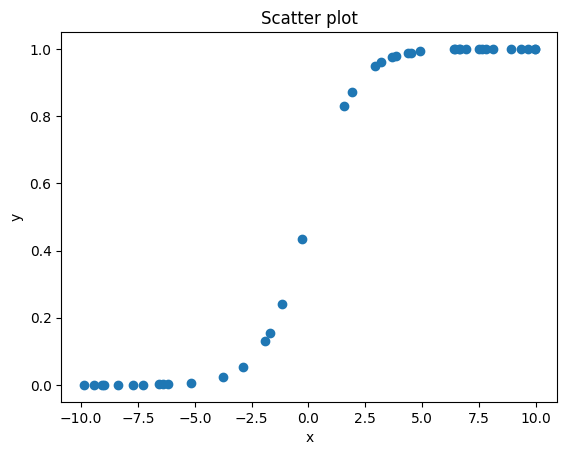

In [69]:
x = np.random.uniform(-10, 10, 40)
print(type(x))
print(x)
visualize(x, 'sigmoid')

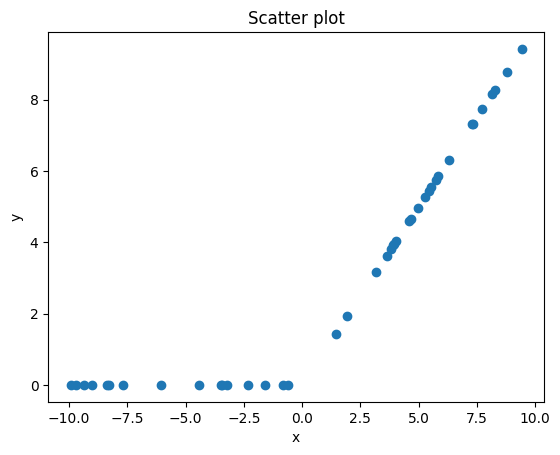

In [57]:
visualize(x, 'relu')

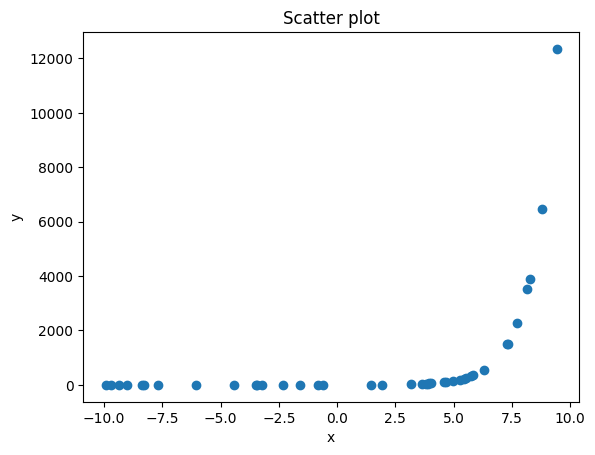

In [63]:
visualize(x, 'elu')

In [71]:
def sigmoid(z):
    return 1 / (1 + math.exp(-z))

def relu(z):
    return max(0, z)

def elu(z, alpha=0.01): 
    if z >= 0:
        return alpha * (math.exp(z) - 1)
    return z

In [81]:
def activation_function(x, activation_func='sigmoid'):
    if not is_number(x):
        print("x must be a number")
        return 0
    
    x = float(x)
    if activation_func not in ['sigmoid', 'relu', 'elu']:
        print(f"{activation_func} is not supported")
        return 0
    
    if activation_func == 'sigmoid':
        return sigmoid(x)
    if activation_func == 'relu':
        return relu(x)
    if activation_func == 'elu':
        return elu(x, alpha=0.01)
    return 0

In [82]:
x = 1.5
name = 'belu'
print(f'{name}({x}):', activation_function(x, name))

belu is not supported
belu(1.5): 0


In [83]:
z = 'abc'
name2 = 'belu'
print(f'{name2}({z}):', activation_function(z, name2))

x must be a number
belu(abc): 0


## 3. Viết hàm lựa chọn hàm mất mát và tính giá trị hàm mất mát (loss functions)

In [97]:
def mae(y_pred, y):
    if y.shape != y_pred.shape:
        raise ValueError("Shape mismatch")
    n = y.shape[0]
    if n == 0:
        print('Number of sample must be more than 0')
        return 0
    return 1 / n * np.sum(np.abs(y - y_pred))  
    
def mse(y_pred, y):
    if y.shape != y_pred.shape:
        raise ValueError("Shape mismatch")
    n = y.shape[0]
    if n == 0:
        print('Number of sample must be more than 0')
        return 0
    return 1/n * np.sum((y - y_pred)**2)

def rmse(y_pred, y):
    if y.shape != y_pred.shape:
        raise ValueError("Shape mismatch")
    n = y.shape[0]
    if n == 0:
        print('Number of sample must be more than 0')
        return 0
    return np.sqrt(1/n * np.sum((y - y_pred)**2))

In [ ]:
def mae(y_pred, y):
    if y.shape != y_pred.shape:
        raise ValueError("Shape mismatch")
    return np.mean(np.abs(y - y_pred))  
    
def mse(y_pred, y):
    if y.shape != y_pred.shape:
        raise ValueError("Shape mismatch")
    return np.mean((y - y_pred)**2)

def rmse(y_pred, y):
    if y.shape != y_pred.shape:
        raise ValueError("Shape mismatch")
    return np.sqrt(np.mean((y - y_pred)**2))

In [99]:
def loss_function(y, y_pred, loss_func='mae'):
    if y.shape != y_pred.shape:
        raise ValueError("Shape mismatch")
    
    if loss_func not in ['mae', 'mse', 'rmse']:
        print(f"{loss_func} is not supported")
        return 0

    if loss_func == 'mae':
        return mae(y, y_pred)
    if loss_func == 'mse':
        return mse(y, y_pred)
    if loss_func == 'rmse':
        return rmse(y, y_pred)
    
    return 0

In [98]:
y = np.array([1,2,3,4,5,6,7])
y_pred = np.array([1.2, 2.4, 3, 4.5, 5.2, 6, 7.8])
print(f'MAE: {mae(y_pred, y)}')
print(f'MSE: {mse(y_pred, y)}')
print(f'RMSE: {rmse(y_pred, y)}')
print(y.shape[0])

MAE: 0.29999999999999993
MSE: 0.16142857142857137
RMSE: 0.40178174601214944
7


In [109]:
np.random.seed(42)
y = np.random.uniform(0, 10, 10)
y_pred = np.random.uniform(0, 10, 10)

print(y)
print(y_pred)
L = loss_function(y, y_pred, loss_func='mse')
print("Loss:",L)

[3.74540119 9.50714306 7.31993942 5.98658484 1.5601864  1.5599452
 0.58083612 8.66176146 6.01115012 7.08072578]
[0.20584494 9.69909852 8.32442641 2.12339111 1.81824967 1.8340451
 3.04242243 5.24756432 4.31945019 2.9122914 ]
Loss: 6.659413573920301


## 4. Viết 4 hàm để ước lượng các hàm số sau

### Sine

$$
\sin(x) \approx \sum_{n=0}^{\infty} (-1)^n \frac{x^{(2n+1)}}{(2n+1)!}
= x - \frac{x^3}{3!} + \frac{x^5}{5!} - \frac{x^7}{7!} + \frac{x^9}{9!} + \cdots
$$

### Cosine

$$
\cos(x) \approx \sum_{n=0}^{\infty} (-1)^n \frac{x^{2n}}{(2n)!}
= 1 - \frac{x^2}{2!} + \frac{x^4}{4!} - \frac{x^6}{6!} + \frac{x^8}{8!} - \frac{x^{10}}{10!} + \cdots
$$

### Sinh

$$
\sinh(x) \approx \sum_{n=0}^{\infty} \frac{x^{(2n+1)}}{(2n+1)!}
= x + \frac{x^3}{3!} + \frac{x^5}{5!} + \frac{x^7}{7!} + \frac{x^9}{9!} + \cdots
$$

### Cosh

$$
\cosh(x) \approx \sum_{n=0}^{\infty} \frac{x^{2n}}{(2n)!}
= 1 + \frac{x^2}{2!} + \frac{x^4}{4!} + \frac{x^6}{6!} + \frac{x^8}{8!} + \frac{x^{10}}{10!} + \cdots
$$

In [117]:
def approx_sin(x, n):
    sum = 0.0
    if not is_number(x):
        print("Input parameters are not numbers")
        return None
    for i in range(n):
        sum += ((-1)**i) * (x**(2*i + 1)) / math.factorial(2*i + 1)
    return sum

def approx_cos(x, n):
    sum = 0.0
    if not is_number(x):
        print("Input parameters are not numbers")
        return None
    for i in range(n):
        sum += ((-1)**i) * (x**(2*i)) / math.factorial(2*i)
    return sum

def approx_sinh(x, n):
    sum = 0.0
    if not is_number(x):
        print("Input parameters are not numbers")
        return None
    for i in range(n):
        sum += (x**(2*i + 1)) / math.factorial(2*i + 1)
    return sum

def approx_cosh(x, n):
    sum = 0.0
    if not is_number(x):
        print("Input parameters are not numbers")
        return None
    for i in range(n):
        sum += (x**(2*i)) / math.factorial(2*i)
    return sum

In [118]:
y = approx_sin(x = 3.14, n=10)
print(y)
y1 = approx_cos(x = 3.14, n=10)
print(y1)
y2 = approx_sinh(x = 3.14, n=10)
print(y2)
y3 = approx_cosh(x = 3.14, n=10)
print(y3)

0.001592652393160744
-0.9999987352210833
11.530292029865986
11.573574824666185


**Bản tối ưu**

In [ ]:
def sin_fast(x, n=10):
    term = x
    s = x
    
    for i in range(1, n):
        term *= -x*x / ((2*i)*(2*i+1))
        s += term
        
    return s

In [ ]:
import math
def is_number(n):
    try:
        float(n)
    except ValueError:
        return False
    return True
assert is_number(3) == 1.0
assert is_number("-2a") == 0.0
print(is_number(1))
print(is_number("n"))